# 2.1 LangChain vs LangGraph (feat. LangGraph 개념 설명)

- LangChain을 활용한 간단한 `llm.invoke()` 예제를 살펴보고, 이를 LangGraph로 구현해보는 과정을 진행합니다.
- LangGraph의 개념과 주요 기능을 이해하고, 두 프레임워크의 차이점을 비교합니다.

## 환경설정

- `LangChain` 활용을 위해 필요한 패키지들을 설치합니다
- 최신 버전을 설치해도 정상적으로 동작해야 하지만, 버전 명시가 필요하다면 `requirements.txt`를 참고해주세요

In [ ]:
# uv로 셋팅했으므로 설치 생략
%pip install -q python-dotenv langchain-openai


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


- 먼저 `.env` 파일의 환경변수를 불러옵니다
- `OPENAI_API_KEY`, `GEMINI_API_KEY`, `ANTHROPIC_API_KEY` 등과 같이 환경변수를 설정하면 편하게 사용할 수 있습니다

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI

query = '인프런에는 어떤 강의가 있나요?'

llm = ChatOpenAI(model='gpt-4o-mini') # 테스트의 경우에는 작은 모델을 사용합니다
llm.invoke(query)

AIMessage(content='인프런(Infrun)은 다양한 분야의 온라인 강의를 제공하는 플랫폼입니다. 주로 IT, 프로그래밍, 데이터 과학, 디자인, 마케팅 등의 주제를 다루고 있습니다. 예를 들어, 다음과 같은 강의 카테고리가 있을 수 있습니다:\n\n1. **프로그래밍**: Python, Java, JavaScript, C++, 웹 개발 등\n2. **데이터 과학**: 데이터 분석, 머신 러닝, 딥러닝, 통계학 등\n3. **디자인**: UX/UI 디자인, 그래픽 디자인, 포토샵, 일러스트레이터 등\n4. **마케팅**: 디지털 마케팅, SEO, 소셜 미디어 마케팅 등\n5. **클라우드**: AWS, Azure, Google Cloud 등 클라우드 서비스 관련 강의\n6. **DevOps**: CI/CD, Docker, Kubernetes 등의 관련 강의\n\n각 강의는 강사에 따라 수준이 다르며, 초급부터 고급까지 다양한 난이도로 구성되어 있습니다. 최신 트렌드에 맞춘 강의도 많으니, 관심 있는 분야를 선택하여 학습할 수 있습니다. 구체적인 강의 목록은 인프런 웹사이트에서 확인할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 268, 'prompt_tokens': 18, 'total_tokens': 286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4c3cd50875', '

- `LangGraph` 활용을 위해 필요한 패키지를 설치합니다
- 최신 버전을 설치해도 정상적으로 동작해야 하지만, 버전 명시가 필요하다면 `requirements.txt`를 참고해주세요

In [4]:
%pip install -q langgraph


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


- `state`는 LangGraph 에이전트의 state를 나타내는 데이터 구조입니다.
- `state`는 `TypedDict`를 사용하여 정의되며, 이는 Python의 타입 힌팅을 통해 구조를 명확히 합니다.
    - 지금 예제에서는 간단하게 `messages`라는 필드만 있습니다.
    - 필요에 따라 다양한 값들을 활용할 수 있습니다.
        - 2.2 회차에서 다룰 예정입니다.
- `state`는 에이전트의 동작을 결정하는 데 사용되며, 각 노드에서 state를 업데이트하거나 참조할 수 있습니다.
- `state`는 LangGraph의 노드 간에 전달되며, 에이전트의 state 전이를 관리합니다.

In [6]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage # SystemMessage, HumanMessage, AIMessage, ChatMessage 등 다양한 메시지 타입이 존재

class AgentState(TypedDict): # state -> TypeDIct -> AnyMessage를 사용
    messages: list[Annotated[AnyMessage, add_messages]]

- 위에 선언한 `AgentState`를 활용하여 `StateGraph`를 생성합니다.

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState) # state 기반의 빌더를 정의

# node -> 작업, edge -> 작업의 연결

- `graph`에 추가할 `node`를 생성합니다
-  `node`는 LangGraph에서 실행되는 개별적인 작업 단위를 의미합니다. 
    - 각 노드는 특정 기능을 수행하는 독립적인 컴포넌트로, 예를 들어 텍스트 생성, 데이터 처리, 또는 의사 결정과 같은 작업을 담당할 수 있습니다.
    - `node`는 기본적으로 함수(function)로 정의되고, 뒤에서 다루지만 다른 에이전트(agent)를 활용할 수도 있습니다

In [8]:
def generate(state: AgentState) -> AgentState: # generate 노드는 state를 인자로 받음
    """
    `generate` 노드는 사용자의 질문을 받아서 응답을 생성하는 노드입니다.
    """
    messages = state['messages'] # messages는 리스트임
    ai_message = llm.invoke(messages) # llm을 호출하여 응답을 생성
    return {'messages': [ai_message]} # state를 반환

- `node`를 생성한 후에 `edge`로 연결합니다
- `edge`는 노드들 사이의 연결을 나타내며, 데이터와 제어 흐름의 경로를 정의합니다. 
    - 엣지를 통해 한 노드의 출력이 다음 노드의 입력으로 전달되어, 전체적인 워크플로우가 형성됩니다.
    - `node`와 `edge`의 조합은 방향성 그래프(Directed Graph)를 형성하며, 이를 통해 복잡한 AI 에이전트의 행동 흐름을 구조화할 수 있습니다

In [ ]:
graph_builder.add_node('generate', generate) # 노드를 추가 -> generate 노드를 추가한 것

- 모든 그래프는 `START(시작)`와 `END(종료)`가 있습니다
    - `END`를 explicit하게 선언하지 않는 경우도 종종 있지만, 가독성을 위해 작성해주는 것을 권장합니다

In [11]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate') # start 노드에서 generate 노드로 연결
graph_builder.add_edge('generate', END) # generate 노드에서 end 노드로 연결 -> start -> generate -> end로 연결된 그래프가 만들어짐

- `node`를 생성하고 `edge`로 연결한 후에 `compile` 메서드를 호출하여 `Graph`를 생성합니다

In [12]:
graph = graph_builder.compile() # 그래프를 컴파일

- `compile` 후에는 그래프를 시각화하여 확인할 수 있습니다
- 의도한대로 그래프가 생성됐는지 확인하는 습관을 기르는 것이 좋습니다
    - `git`에서 코드 작업물을 commit하기 전에 `git diff`를 통해 변경사항을 확인하는 것과 같습니다

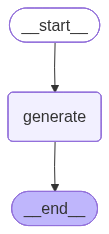

In [13]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png())) # 그래프를 시각화하여 보여줌

In [ ]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]} # state를 만들어 generate 노드가 포함된 그래프를 실행
graph.invoke(initial_state) # 그래프도 invoke 메서드를 통해 실행

{'messages': [AIMessage(content='인프런(Infrun)은 다양한 온라인 강의를 제공하는 플랫폼으로, 주로 IT, 프로그래밍, 데이터 분석, 디자인, 마케팅 등의 분야에서 다양한 강의를 찾을 수 있습니다. 예를 들어:\n\n1. **프로그래밍**: Python, Java, JavaScript, C++, 등 다양한 프로그래밍 언어에 대한 강의.\n2. **웹 개발**: HTML, CSS, React, Node.js 등을 포함한 웹 개발 관련 강의.\n3. **데이터 분석**: 데이터 분석, 머신러닝, 인공지능 관련 강의.\n4. **디자인**: UI/UX 디자인, 그래픽 디자인, 포토샵, 일러스트레이터 강의.\n5. **모바일 개발**: 안드로이드, iOS 앱 개발 관련 강의.\n6. **클라우드**: AWS, Azure 등 클라우드 컴퓨팅 관련 강의.\n7. **마케팅**: 디지털 마케팅, SEO, 소셜 미디어 마케팅 관련 강의.\n\n각 강의는 강사에 따라 내용과 수준이 다르므로, 자신의 필요에 맞는 강의를 선택할 수 있습니다. 인프런의 웹사이트를 방문하면 최신 강의 목록과 세부 정보를 확인할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 267, 'prompt_tokens': 18, 'total_tokens': 285, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_